# Cumberland Transient PEST Results Review

Use this notebook **after a transient Cumberland PEST run has finished** to reopen the baseline and calibrated models, inspect the final `K` field, and compare head residuals without rerunning calibration.


## Imports and target helpers

Load `myflopy`, plotting tools, and a small helper that rebuilds the known Cumberland transient target set used by older runs. Newer runs should be able to reopen their saved targets directly from workspace metadata.


In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd().resolve()
src = project_root / "src"
if str(src) not in sys.path:
    sys.path.insert(0, str(src))

import myflopy as mf

DEFAULT_CALIB_LOCS = Path(r"C:\Users\lukem\mf6\Cumberland general\Boundaries\calibration_locs.gpkg")
DEFAULT_CALIB_OBS = Path(r"C:\Users\lukem\mf6\Cumberland general\Tables\calib_observations.xlsx")
DEFAULT_MERGED_WELLS = Path(r"C:\Users\lukem\QGIS\SHP\Cumberland\explo cumberland merged.gpkg")
DEFAULT_BORING_SUMMARY = Path(r"C:\Users\lukem\mf6\Cumberland general\Boring Summary.csv")


def resolve_completed_run_ref(path_like):
    path = Path(path_like)
    if path.suffix.lower() == ".txt":
        target = path.read_text(encoding="utf-8").strip()
        if not target:
            raise ValueError(f"Pointer file is empty: {path}")
        return Path(target)
    return path


def build_default_targets(
    source_start_per=57,
    n_transient=12,
    supplemental_weight=0.25,
    calib_locs=DEFAULT_CALIB_LOCS,
    calib_obs=DEFAULT_CALIB_OBS,
    merged_wells=DEFAULT_MERGED_WELLS,
    boring_summary=DEFAULT_BORING_SUMMARY,
):
    obs_frame = pd.read_excel(calib_obs).sort_values("per").reset_index(drop=True)
    source_periods = list(range(int(source_start_per), int(source_start_per) + int(n_transient)))
    selected_obs = obs_frame.loc[obs_frame["per"].isin(source_periods)].copy()
    if selected_obs["per"].astype(int).tolist() != source_periods:
        raise ValueError(f"Could not reconstruct the expected source periods: {source_periods}")

    locs = gpd.read_file(calib_locs).copy()
    locs["name"] = locs["ExploName"].astype(str)
    locs["layer_num"] = 0
    locs["weight"] = 1.0
    allowed_names = set(locs["name"].tolist())

    rows = []
    well_columns = [column for column in selected_obs.columns if column != "per"]
    for transient_offset, (_, row) in enumerate(selected_obs.iterrows(), start=1):
        for name in well_columns:
            if name not in allowed_names:
                continue
            value = row[name]
            if pd.isna(value):
                continue
            rows.append({"per": transient_offset, "name": str(name), "head": float(value)})

    supplemental_alias = {
        "MW-1 (HWA)": "MW1_HWA",
        "MW-2 (HWA)": "MW2_HWA",
        "MW-3 (HWA)": "MW3_HWA",
        "MW-4 (HWA)": "MW4_HWA",
        "B-1 (GD)": "B1_GD",
        "B-2 (GD)": "B2_GD",
    }
    supplemental_names = list(supplemental_alias.keys())
    merged = gpd.read_file(merged_wells).copy()
    merged["name"] = merged["ExploName"].astype(str)
    merged = merged.loc[merged["name"].isin(supplemental_names), ["name", "geometry"]].copy()
    merged["name"] = merged["name"].map(supplemental_alias)
    merged["layer_num"] = 0
    merged["weight"] = float(supplemental_weight)

    boring = pd.read_csv(boring_summary).copy()
    boring["name"] = boring["Boring"].astype(str)
    boring["gw_elev"] = pd.to_numeric(boring["GW Elev. (ft)"], errors="coerce")
    boring = boring.loc[boring["name"].isin(supplemental_names), ["name", "gw_elev"]].copy()
    overrides = {"B-1 (GD)": 836.0, "B-2 (GD)": 800.0}
    for name, value in overrides.items():
        if name in boring["name"].tolist():
            boring.loc[boring["name"] == name, "gw_elev"] = value
        else:
            boring = pd.concat([boring, pd.DataFrame([{"name": name, "gw_elev": value}])], ignore_index=True)
    boring["name"] = boring["name"].map(supplemental_alias)
    rows.extend(
        {"per": 0, "name": str(row.name), "head": float(row.gw_elev)}
        for row in boring.itertuples(index=False)
        if pd.notna(row.gw_elev)
    )

    target_values = pd.DataFrame(rows)
    active_names = sorted(target_values["name"].unique().tolist())
    locs = locs.loc[locs["name"].isin(active_names), ["name", "layer_num", "weight", "geometry"]].copy()
    merged = merged.loc[merged["name"].isin(active_names), ["name", "layer_num", "weight", "geometry"]].copy()
    combined_locs = pd.concat([locs, merged], ignore_index=True).drop_duplicates(subset=["name"], keep="first")
    targets = mf.HeadTargets(
        locations=combined_locs,
        values=target_values,
        name_column="name",
        layer_column="layer_num",
        time_column="per",
        value_column="head",
    )
    return targets, target_values, source_periods


## Point to the completed run

Set this to one of these:

- the finished artifact folder
- the finished parallel `pest_master` folder
- or the `*_latest.txt` pointer file written by the transient script

The target settings below match the current default transient calibration workflow. Change them only if you deliberately ran the script with a different source period window or supplemental weight.


In [2]:
completed_run_ref = Path(r'C:\Users\lukem\Python\Projects\myflopy\examples\mf6\artifacts\cumberland_transient_observed_pest_first_slice_20260519_120906\pest_master')
source_start_per = 57
n_transient = 12
supplemental_weight = 0.25


## Reopen the baseline and calibrated models

Resolve the completed run path, open it through the built-in `mf.open_pest_run(...)` API, and generate `baseline_model` plus `completed_model` directly from the finished `.par` file. For target review, the notebook first tries the saved workspace metadata and only falls back to the older hardcoded Cumberland reconstruction if that metadata is missing.


In [3]:
completed_run_dir = resolve_completed_run_ref(completed_run_ref)
print(completed_run_dir)
pest_run = mf.open_pest_run(completed_run_dir)

if not pest_run.has_final_parameters:
    raise FileNotFoundError(
        "No final .par file was found in this workspace. Pick a completed run that finished successfully."
    )

baseline_model = pest_run.load_baseline_model()
completed_model = pest_run.load_calibrated_model()

try:
    targets = pest_run.load_head_targets()
    target_values = targets.to_long().rename(columns={"head_target": "head", "time": "per"})
    target_source = "saved workspace metadata"
    per_series = pd.to_numeric(target_values["per"], errors="coerce").dropna().astype(int)
    source_periods = sorted(value for value in per_series.unique().tolist() if value > 0)
except (FileNotFoundError, ValueError) as exc:
    print(f"Falling back to rebuilt Cumberland targets: {exc}")
    targets, target_values, source_periods = build_default_targets(
        source_start_per=source_start_per,
        n_transient=n_transient,
        supplemental_weight=supplemental_weight,
    )
    target_source = "rebuilt Cumberland defaults"

review = pest_run.review(targets)

display(pest_run.summary())
print(f"Resolved run: {completed_run_dir}")
print(type(baseline_model))
print(type(completed_model))
print(f"Target source: {target_source}")
print(f"Source periods: {source_periods}")
target_location_count = review.targets.locations_gdf["name"].nunique()
print(f"Targets loaded: {len(review.targets.get())} rows across {target_location_count} locations")


C:\Users\lukem\Python\Projects\myflopy\examples\mf6\artifacts\cumberland_transient_observed_pest_first_slice_20260519_120906\pest_master
FloPy is using the following executable to run the model: ..\..\..\..\..\..\..\PATH\modflow_exe\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.2 05/12/2025

   MODFLOW 6 compiled May 24 2025 11:42:11 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material 

C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:329: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:2926
Right CRS: EPSG:2927

  joined = gpd.sjoin(


VoronoiGrid initializing.
Voronoi grid initialized.


C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:329: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:2926
Right CRS: EPSG:2927

  joined = gpd.sjoin(
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:329: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:2926
Right CRS: EPSG:2927

  joined = gpd.sjoin(
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:329: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:2926
Right CRS: EPSG:2927

  joined = gpd.sjoin(


,root,baseline_workspace,pest_workspace,pst,par,rec,metadata,materialization,n_saved_head_target_sets,has_final_parameters
0,C:\Users\lukem\Python\Projects\myflopy\...,C:\Users\lukem\Python\Projects\myflopy\...,C:\Users\lukem\Python\Projects\myflopy\...,cpre_obs_13p.pst,cpre_obs_13p.par,cpre_obs_13p.rec,None,myflopy_calibrated_materialization.json,0,True


Resolved run: C:\Users\lukem\Python\Projects\myflopy\examples\mf6\artifacts\cumberland_transient_observed_pest_first_slice_20260519_120906\pest_master
<class 'myflopy.project.run_model.LoadedMf6Run'>
<class 'myflopy.project.run_model.LoadedMf6Run'>
Target source: rebuilt Cumberland defaults
Source periods: [57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]
Targets loaded: 129 rows across 17 locations


## Inspect the finished PEST files

List the key output files from the completed run so it is easy to jump into the `.rec`, `.rei`, `.par`, and related outputs.


In [4]:
sorted(path.name for path in pest_run.pest_workspace.iterdir() if path.suffix.lower() in {".pst", ".rec", ".rei", ".par", ".phi", ".jcb", ".csv"})


['cpre_obs_13p.0.fosm_reweight.rei',
 'cpre_obs_13p.0.par.usum.csv',
 'cpre_obs_13p.1.par',
 'cpre_obs_13p.fosm_reweight.rei',
 'cpre_obs_13p.jcb',
 'cpre_obs_13p.par',
 'cpre_obs_13p.par.usum.csv',
 'cpre_obs_13p.pst',
 'cpre_obs_13p.rec',
 'cpre_obs_13p.rei',
 'cpre_obs_13p.upg.csv',
 'hds_head_target_map.csv',
 'hds_simulated_heads.csv',
 'hk_pilot_points.cells.csv',
 'hk_pilot_points.csv',
 'hk_pilot_points.final.csv',
 'hk_pilot_points.meta.csv',
 'ims_inner_convergence.csv',
 'ims_outer_convergence.csv']

## Plot the final `K` field

Use the reopened calibrated model to map the final `K` values and the ratio relative to the baseline `K` field.


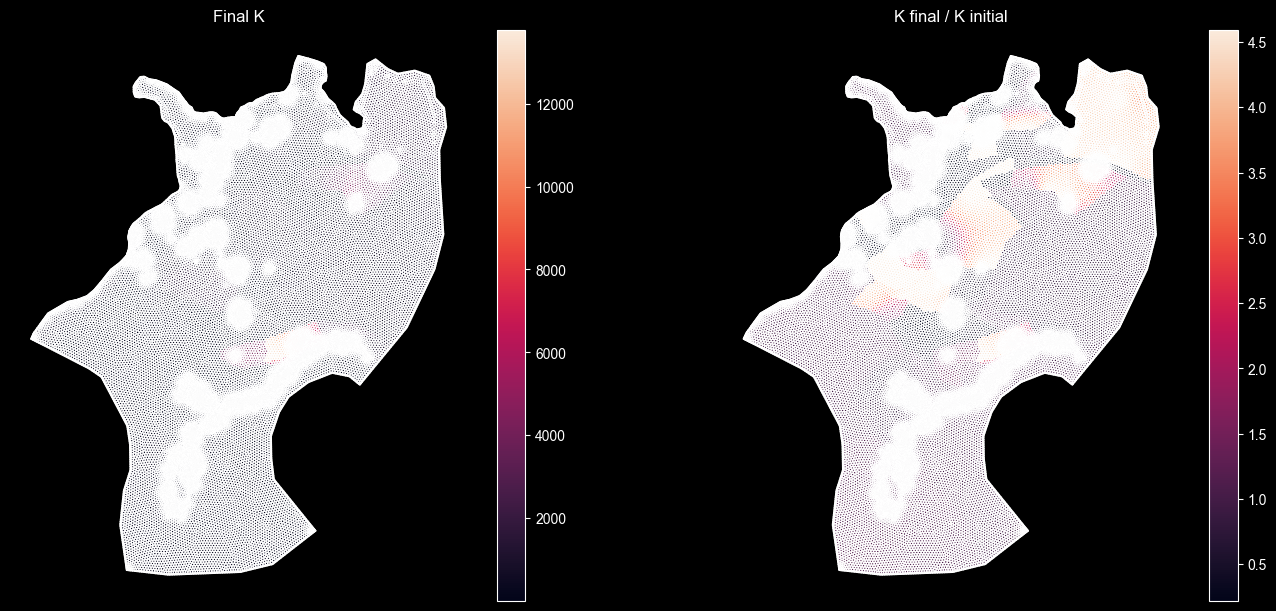

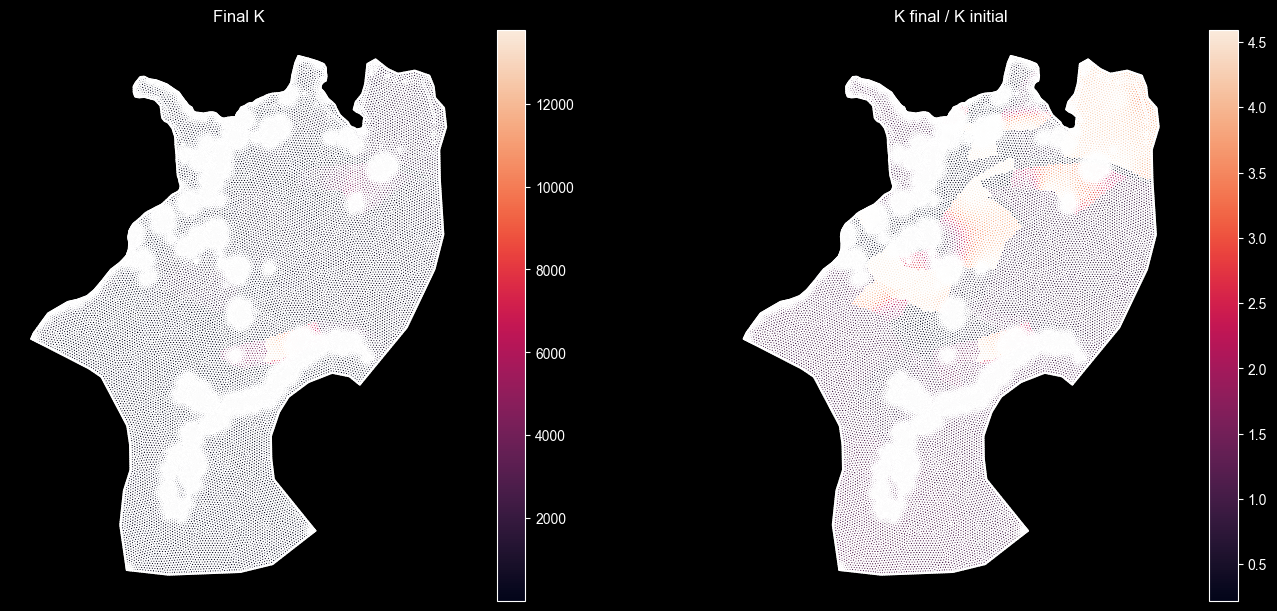

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
pest_run.plot_k(ax=axes[0])
pest_run.plot_k_ratio(ax=axes[1])

fig


## Compare residuals before and after calibration

Use the discovered target set and the built-in `PestRunResults` helpers to compare baseline and calibrated residuals.


In [6]:
residual_compare = review.residual_compare
residual_compare.loc[:, [
    "name",
    "time",
    "head_target",
    "sim_head_baseline",
    "sim_head_calibrated",
    "residual_baseline",
    "residual_calibrated",
    "abs_residual_improvement",
]].sort_values(["time", "name"]).reset_index(drop=True)


,name,time,head_target,sim_head_baseline,sim_head_calibrated,residual_baseline,residual_calibrated,abs_residual_improvement
0,B1_GD,0,836.000000,831.5893,831.569007,-4.4107,-4.430993,-0.020294
1,B2_GD,0,800.000000,800.058266,800.004948,0.058266,0.004948,0.053318
2,MW1_HWA,0,725.000000,719.533824,717.126664,-5.466176,-7.873336,-2.40716
3,MW2_HWA,0,763.000000,755.440813,755.16929,-7.559187,-7.83071,-0.271523
4,MW3_HWA,0,759.000000,747.610982,741.479217,-11.389018,-17.520783,-6.131766
...,...,...,...,...,...,...,...,...
124,EB-4W,12,710.950257,705.406432,719.905131,-5.543825,8.954874,-3.411049
125,EB-5W,12,703.546549,697.455905,698.162155,-6.090644,-5.384394,0.70625
126,EB-7W,12,720.562334,711.2632,704.495164,-9.299134,-16.06717,-6.768036
127,EB-8W,12,716.574128,708.250859,711.273898,-8.323269,-5.30023,3.023039


In [ ]:
review.stats


## Residual summary by model period

This is useful for spotting whether calibration helped only certain months or improved the full transient sequence.


In [7]:
residual_compare.groupby("time").agg(
    n=("name", "count"),
    mae_baseline=("abs_residual_baseline", "mean"),
    mae_calibrated=("abs_residual_calibrated", "mean"),
    mean_improvement=("abs_residual_improvement", "mean"),
).reset_index()


,time,n,mae_baseline,mae_calibrated,mean_improvement
0,0,6,8.173792,8.502239,-0.328447
1,1,10,6.00656,6.42908,-0.42252
2,2,10,5.592588,6.747233,-1.154645
3,3,10,4.155177,5.841872,-1.686695
4,4,10,3.050236,5.057583,-2.007346
5,5,10,3.16247,4.891255,-1.728785
6,6,10,3.422404,4.689678,-1.267274
7,7,10,4.157591,5.04236,-0.884769
8,8,10,4.578068,5.244214,-0.666146
9,9,10,5.695885,5.806003,-0.110118


## Inspect one well through time

Pick one well name and plot the target, baseline simulation, and calibrated simulation through the transient calibration window.


C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:329: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:2926
Right CRS: EPSG:2927

  joined = gpd.sjoin(
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:329: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:2926
Right CRS: EPSG:2927

  joined = gpd.sjoin(


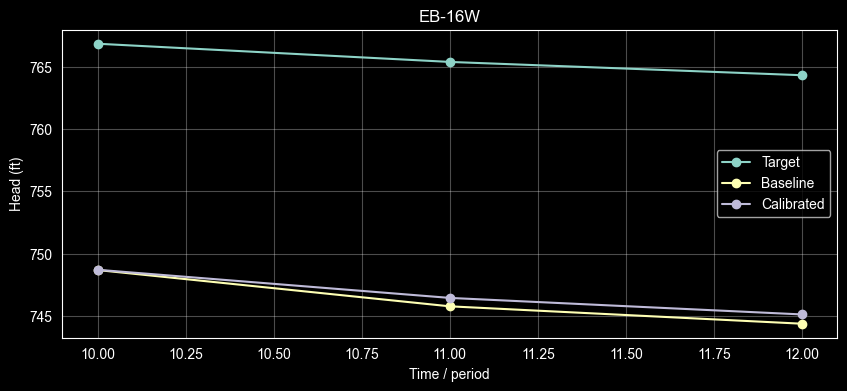

In [14]:
well_name = sorted(residual_compare["name"].unique())[4]
fig, ax = plt.subplots(figsize=(10, 4))
pest_run.plot_well_timeseries(well_name, targets=review.targets, ax=ax)
ax.set_ylabel("Head (ft)")
plt.show()


In [17]:
completed_model.cor(type='ks').plot()